# Count the leaves

**Week 1, Monday. Round 2 of 3: how many customers, how often do they buy, and what is revenue per
order?**

Meera Raghavan, CEO of Kalpa Retail, is weighing marketing's request for Rs 12 crore to win new
customers. Her question for this round is the one that decides whether that request is aimed at
the right branch:

> "Is acquisition even the branch that is short?"

> **Kavya's review.** A customer is a person and an order is a row. The day you mix those two up,
> every rate you report is wrong in a way nobody downstream can see, so count people by their id
> and say how you did it.

Round 1 established what sales is on this extract: Rs 5,44,810 booked on 30 orders, Rs 5,35,760 net
of cancellations and Rs 5,20,790 delivered, with the definition stated beside every number. It also
turned each branch of the tree into a metric. This round fills in the two branches round 1 left
open, customers and orders per customer, and checks that the tree multiplies back to revenue.

**Setup.** The first cell finds the shared helper, `c2kit`, by walking up from this folder until it
reaches `scripts/`, then loads the 30 orders from `../data/` as `ORDERS`, a list of dictionaries.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()
print(len(ORDERS), "orders loaded")

30 orders loaded


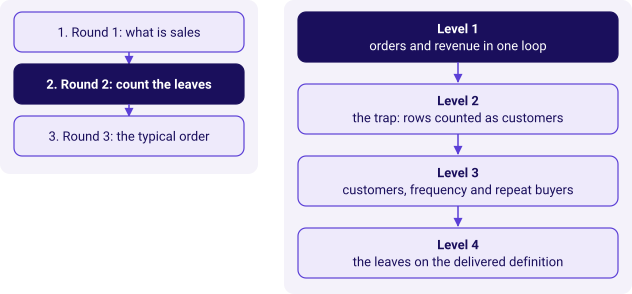

In [2]:
kit.side_by_side(
    kit.ladder(["Round 1: what is sales", "Round 2: count the leaves", "Round 3: the typical order"],
               lit=1, show=False),
    kit.vflow(["Level 1\norders and revenue in one loop",
               "Level 2\nthe trap: rows counted as customers",
               "Level 3\ncustomers, frequency and repeat buyers",
               "Level 4\nthe leaves on the delivered definition"], lit=0, show=False),
)

## 1. Orders and revenue come out of one loop

Two leaves can be counted in a single pass: a count that adds one per order, and a sum that adds
each order's amount. Both are accumulators with the same three moves, start before the loop, update
once per order inside it, and read after it. Round 1 wrapped every amount in `int()`; this loop
takes the `int()` away, which is how most people first write it.

**Predict before you run.** What does the cell print?

- a) 30 orders and Rs 5,44,810, the same as round 1.
- b) 30 orders and a total smaller than round 1's.
- c) An error part of the way through the list.
- d) 0 and 0, because the totals start at zero.

The `with kit.expect_error()` line catches the error so the notebook keeps running; on your own
screen, without it, Jupyter prints a longer trace ending on the same last line.

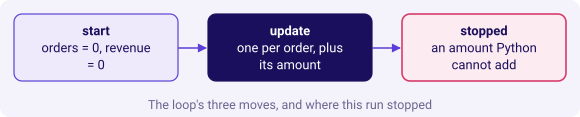

In [3]:
with kit.expect_error() as stopped:
    orders = 0
    revenue = 0
    for order in ORDERS:
        orders += 1
        revenue += order["amount"]
    print(orders, revenue)
kit.flow(["start\norders = 0, revenue = 0", "update\none per order, plus its amount",
          "stopped\nan amount Python cannot add"], kinds=[None, "lit", "bad"],
         title="The loop's three moves, and where this run stopped")

**What happened.** The answer is c. This is what Jupyter prints without the `with` line, and it is
read from the last line up:

```text
TypeError                                 Traceback (most recent call last)
Cell In[3], line 5
      3 for order in ORDERS:
      4     orders += 1
----> 5     revenue += order["amount"]
      6 print(orders, revenue)

TypeError: unsupported operand type(s) for +=: 'int' and 'str'
```

The last line names the kind of problem, a `TypeError`, the operation, `+=`, and the two sides: a
whole number on the left, the running total, and text on the right. Somewhere in the list one
amount was stored as text, and Python will not add text to a number. That is worth two minutes
and no more.

**Your turn.** Two names survive the stop: `orders` holds how many orders the loop had counted, and
`order` holds the record it stopped on. Type these three lines into the empty cell below and run
it, then say in one sentence what is odd about that record:

```python
print(orders, "orders counted before the stop")
print(order)
print(type(order["amount"]))
```

**The fix for today** is `int()`, which turns text that looks like a whole number into a number, so
every amount can be added. Why an amount arrived as text, and whether a bigger file holds more of
them, is Wednesday's question.

30 orders, Rs 5,44,810 booked


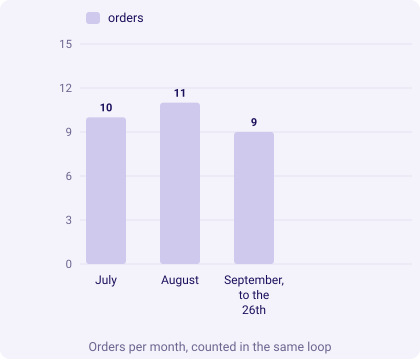

In [4]:
orders = 0
revenue = 0
by_month = {"07": 0, "08": 0, "09": 0}
for order in ORDERS:
    orders += 1
    revenue += int(order["amount"])
    by_month[order["order_date"][5:7]] += 1
print(orders, "orders,", kit.rupees(revenue), "booked")
kit.columns(["July", "August", "September, to the 26th"], [("orders", list(by_month.values()))],
            width=420, title="Orders per month, counted in the same loop")

In [5]:
kit.check("the first loop stopped on a TypeError", stopped.name == "TypeError", stopped.message)
kit.check("the error came from adding text to a number", "'int' and 'str'" in stopped.message)
kit.check("with int(), all 30 orders are counted", orders == 30, orders)
kit.check("with int(), booked revenue matches round 1", revenue == 544810, kit.rupees(revenue))

## 2. The trap: every row counted as a customer

Orders per customer is orders divided by customers. The fastest way to get "customers" out of a
list is to count the list, and that is the step a hurried analyst takes.

**Predict before you run.** The next cell divides orders by the number of rows. What orders-per-
customer figure does it report?

- a) 1.00, one order for every customer.
- b) 1.30, the figure the tree needs.
- c) 0.77, because customers outnumber orders.
- d) 23.00, because the division runs the wrong way.

**The plausible wrong answer.** The cell a hurried analyst writes:

Customers: 30
Orders per customer: 1.00, so nobody comes back


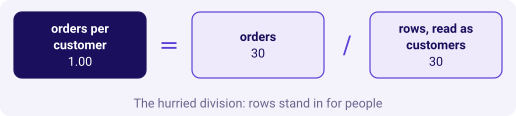

In [6]:
customers_hurried = len(ORDERS)
per_customer_hurried = orders / customers_hurried
print("Customers:", customers_hurried)
print(f"Orders per customer: {per_customer_hurried:.2f}, so nobody comes back")
kit.equation(["orders per customer\n" + f"{per_customer_hurried:.2f}", "=", "orders\n30", "/",
              "rows, read as customers\n30"], title="The hurried division: rows stand in for people")

**What happened.** The answer is a. The division is correct and its denominator is wrong.

**Why it is wrong.** A row is an order, and one customer can place several. Reported to Meera,
"1.00 orders per customer, nobody comes back" says that frequency is a dead branch and that the only
way to grow is to buy new customers, which is exactly the case for marketing's Rs 12 crore. The
check below compares the number of customer ids in the list with the number of distinct ones. A
`set` keeps each value once, however many times it is added, so its length is the count of distinct
customers.

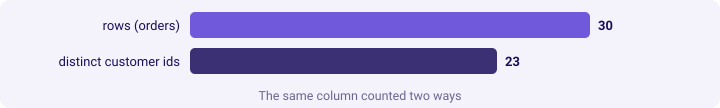

In [7]:
ids = []
for order in ORDERS:
    ids.append(order["customer_id"])
distinct = set(ids)
kit.bars([("rows (orders)", len(ids)), ("distinct customer ids", len(distinct))], lit=(1,),
         title="The same column counted two ways")
kit.check("the list holds one id per row", len(ids) == 30, len(ids))
kit.check("the set holds 23 distinct customers", len(distinct) == 23, len(distinct))
kit.check("rows overstate customers, so the hurried rate is wrong", len(ids) > len(distinct),
          f"{len(ids)} rows against {len(distinct)} customers")

**The fix.** Divide by distinct customers.

In [8]:
customers = len(distinct)
per_customer = orders / customers
kit.table(["leaf", "hurried", "fixed", "what changed"],
          [("customers", customers_hurried, customers, f"{customers_hurried - customers} fewer: they were repeat orders"),
           ("orders per customer", f"{per_customer_hurried:.2f}", f"{per_customer:.2f}", "somebody came back")],
          caption="The trap and its fix, side by side")
kit.check("orders per customer is 1.30 on distinct customers", round(per_customer, 2) == 1.30, f"{per_customer:.2f}")

leaf,hurried,fixed,what changed
customers,30,23,7 fewer: they were repeat orders
orders per customer,1.00,1.30,somebody came back


What changed: customers fall from 30 to 23, and orders per customer rises from 1.00 to 1.30. Seven
more orders than customers means some customers came back, so frequency is a live branch, and the
Rs 12 crore case can no longer rest on "nobody comes back". Level 3 counts who came back.

> **Kavya's review.** The division was fine; the denominator was a guess. Every rate you send
> upstairs carries the name of its denominator, and a count of people comes from their ids.

## 3. A dictionary counts orders per customer, and the tree multiplies back

A set says how many distinct customers there are. It cannot say how many orders each one placed,
because it keeps each id once and forgets the rest. A dictionary can: the customer id is the key and
the count of that customer's orders is the value, updated once per order.

**Predict before you run.** Of the 23 customers, how many bought more than once in the quarter?

- a) None, because orders per customer is close to 1.
- b) 23, because the rate is above 1.
- c) 16, the customers who are not new.
- d) 7, the difference between 30 orders and 23 customers.

16 customers bought once, 7 bought more than once (30% of customers came back)


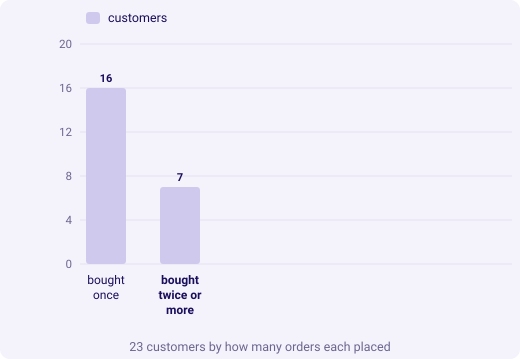

In [9]:
counts = {}
for order in ORDERS:
    cid = order["customer_id"]
    if cid in counts:
        counts[cid] += 1
    else:
        counts[cid] = 1

once = 0
repeat = 0
for cid in counts:
    if counts[cid] == 1:
        once += 1
    else:
        repeat += 1
print(f"{once} customers bought once, {repeat} bought more than once ({repeat / customers:.0%} of customers came back)")
kit.columns(["bought once", "bought twice or more"], [("customers", [once, repeat])], lit=(1,), width=520,
            title="23 customers by how many orders each placed")

**What happened.** The answer is d. Sixteen customers bought once and seven bought twice, so 30
percent of customers came back within one quarter. Here the difference between orders and customers
equals the number of repeat buyers because nobody bought three times; with a third order the two
would part company, which is why the dictionary is the count to trust.

The table below lists the seven repeat buyers. One of them, C-0107, appears once as Retail-Core and
once as Retail-Plus, because the segment is recorded on each order; a count of customers per segment
has to say which order's segment it used.

In [10]:
rows = []
for cid in sorted(counts):
    if counts[cid] > 1:
        channels, statuses, segments = [], [], []
        for order in ORDERS:
            if order["customer_id"] == cid:
                channels.append(order["channel"])
                statuses.append(order["status"])
                segments.append(order["segment"])
        rows.append((cid, counts[cid], ", ".join(channels), ", ".join(statuses), ", ".join(sorted(set(segments)))))
kit.table(["customer", "orders", "channels", "statuses", "segments on their orders"], rows,
          caption="The seven customers who came back")

customer,orders,channels,statuses,segments on their orders
C-0101,2,"app, web","delivered, returned",Retail-Core
C-0102,2,"web, store","delivered, cancelled",Retail-Core
C-0103,2,"store, app","delivered, delivered",Student
C-0104,2,"app, web","delivered, delivered",Retail-Plus
C-0105,2,"web, store","returned, delivered",Retail-Core
C-0106,2,"store, app","cancelled, delivered",Retail-Plus
C-0107,2,"app, web","delivered, returned","Retail-Core, Retail-Plus"


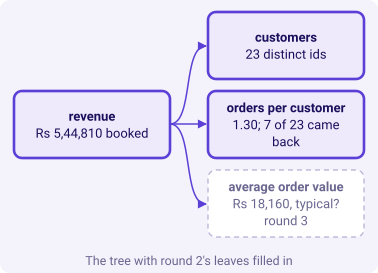

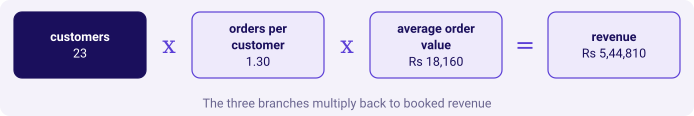

In [11]:
average_order_value = revenue / orders
rebuilt = customers * per_customer * average_order_value
kit.driver_tree({"label": "revenue", "note": kit.rupees(revenue) + " booked", "kind": "known", "children": [
    {"label": "customers", "note": f"{customers} distinct ids", "kind": "known"},
    {"label": "orders per customer", "note": f"{per_customer:.2f}; {repeat} of {customers} came back", "kind": "known"},
    {"label": "average order value", "note": kit.rupees(average_order_value) + ", typical? round 3", "kind": "unknown"}]},
    title="The tree with round 2's leaves filled in")
kit.equation([f"customers\n{customers}", "x", f"orders per customer\n{per_customer:.2f}", "x",
              "average order value\n" + kit.rupees(average_order_value), "=", "revenue\n" + kit.rupees(rebuilt)],
             title="The three branches multiply back to booked revenue")

In [12]:
kit.check("16 customers bought once and 7 came back", (once, repeat) == (16, 7), f"{once} and {repeat}")
kit.check("every customer is counted exactly once", once + repeat == customers)
kit.check("the counts add back to 30 orders", sum(counts.values()) == orders, sum(counts.values()))
kit.check("customers x orders per customer x average order value = booked revenue",
          round(rebuilt) == 544810, kit.rupees(rebuilt))

## 4. The leaves move when the definition moves

Round 1 showed that "sales" has more than one reading. Every leaf inherits that choice: a cancelled
order drops out of orders, and a customer whose only order was cancelled drops out of customers.
The room's harder variant counts all four leaves under each definition in one loop per definition.

**Predict before you run.** On the delivered definition, what happens to orders per customer?

- a) It stays at 1.30, because it is a ratio and both sides shrink.
- b) It falls, because orders shrink faster than customers do.
- c) It rises, because the customers who remain are the loyal ones.
- d) It cannot be computed without the returned orders.

definition,orders,customers,orders per customer,came back,revenue
booked,30,23,1.30,7,"Rs 5,44,810"
not cancelled,26,21,1.24,5,"Rs 5,35,760"
delivered,21,19,1.11,2,"Rs 5,20,790"


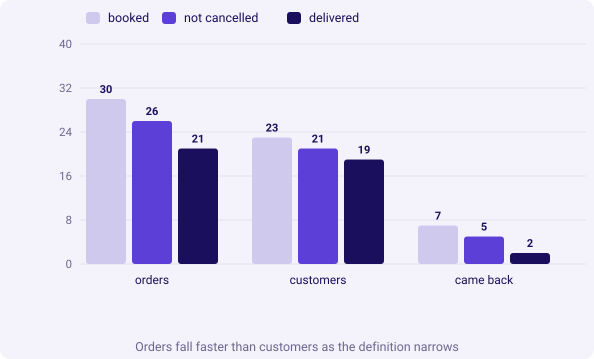

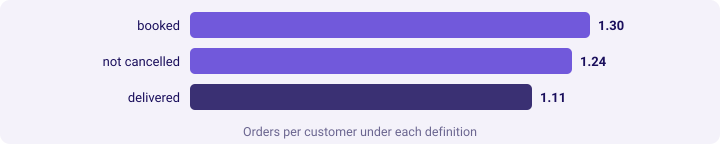

In [13]:
definitions = {
    "booked": {"delivered", "returned", "cancelled"},
    "not cancelled": {"delivered", "returned"},
    "delivered": {"delivered"},
}
leaves = {}
for name in definitions:
    keep = definitions[name]
    n, rupees, people, per_person = 0, 0, set(), {}
    for order in ORDERS:
        if order["status"] in keep:
            n += 1
            rupees += int(order["amount"])
            people.add(order["customer_id"])
            per_person[order["customer_id"]] = per_person.get(order["customer_id"], 0) + 1
    came_back = 0
    for cid in per_person:
        if per_person[cid] > 1:
            came_back += 1
    leaves[name] = {"orders": n, "customers": len(people), "per customer": n / len(people),
                    "revenue": rupees, "came back": came_back}

kit.table(["definition", "orders", "customers", "orders per customer", "came back", "revenue"],
          [(name, v["orders"], v["customers"], f'{v["per customer"]:.2f}', v["came back"], kit.rupees(v["revenue"]))
           for name, v in leaves.items()],
          caption="The four leaves under each definition of sales")
names = list(leaves)
kit.columns(["orders", "customers", "came back"],
            [(name, [leaves[name]["orders"], leaves[name]["customers"], leaves[name]["came back"]]) for name in names],
            title="Orders fall faster than customers as the definition narrows")
kit.bars([(name, round(leaves[name]["per customer"], 2)) for name in names], fmt=lambda v: f"{v:.2f}",
         lit=(2,), title="Orders per customer under each definition")

**What happened.** The answer is b. On the delivered definition there are 21 orders from 19
customers, 1.11 orders per customer, on Rs 5,20,790. Removing the 9 cancelled and returned orders
removes only 4 customers, because most of those orders belonged to people who also had another
order. The sharpest change is in repeat buyers: of the 7 customers who came back, only 2 had both
orders delivered. For Meera, frequency is a live branch that leaks: customers do return, and their
second orders are the ones that most often get cancelled or sent back.

In [14]:
d, n = leaves["delivered"], leaves["not cancelled"]
kit.check("delivered: 21 orders from 19 customers", (d["orders"], d["customers"]) == (21, 19), (d["orders"], d["customers"]))
kit.check("delivered: 1.11 orders per customer on Rs 5,20,790",
          round(d["per customer"], 2) == 1.11 and d["revenue"] == 520790, f'{d["per customer"]:.2f}')
kit.check("not cancelled: 26 orders from 21 customers, 1.24 each",
          (n["orders"], n["customers"], round(n["per customer"], 2)) == (26, 21, 1.24))
kit.check("only 2 customers came back with both orders delivered", d["came back"] == 2, d["came back"])

### In the interview

**[SV] A list against a dictionary: when do you reach for each?** "A list when order matters or when
I will walk every item, like thirty orders in the order they arrived. A dictionary when I look
things up by a key, like one field of an order or a running count per customer. Real records are
usually both: a list of dictionaries, one dictionary per row, which is what a JSON array from an API
looks like. Checking whether a value is in a list walks every item, while a dictionary goes straight
to its key, which starts to matter once the file has a million rows."

**[F] Your extract shows 30 orders and 30 customers; what do you check before saying nobody comes
back?** "Whether 30 customers means 30 distinct customer ids or 30 rows. I compare the length of
the id column with the length of its set; here that is 30 against 23, so seven orders came from
people who had already bought. I would also check the window, because a customer who buys every
four months will look like a one-time buyer in a single quarter, and whether the same person can
appear under two ids."

**[SV] How do you count distinct customers in Python, and why does a set give the answer a list does
not?** "Put the customer ids into a set, `set(ids)`, and take its length. A set keeps each value
once however many times it is added, so its length is the count of distinct values, while a list
keeps every occurrence, so its length is the count of rows. When I also need how many orders each
customer placed, I use a dictionary keyed by customer id."

### Depth: two shorter ways to write the same counts, and a set question worth asking

`counts.get(cid, 0) + 1` does the work of the four-line `if` and `else`: `get` returns the value
under the key, or the default when the key is missing. Sets also answer questions about overlap: `&`
keeps the ids two sets share and `|` keeps the ids in either.

In [15]:
channels_by_customer = {}
for order in ORDERS:
    channels_by_customer.setdefault(order["customer_id"], set()).add(order["channel"])
app_ids, web_ids, store_ids = set(), set(), set()
for order in ORDERS:
    {"app": app_ids, "web": web_ids, "store": store_ids}[order["channel"]].add(order["customer_id"])
two_channels = 0
for cid in channels_by_customer:
    if len(channels_by_customer[cid]) > 1:
        two_channels += 1
kit.table(["question", "set expression", "answer"],
          [("customers who bought on the app", "len(app_ids)", len(app_ids)),
           ("customers who bought on both app and web", "len(app_ids & web_ids)", len(app_ids & web_ids)),
           ("customers who bought on any channel", "len(app_ids | web_ids | store_ids)", len(app_ids | web_ids | store_ids)),
           ("customers who used more than one channel", "len(channels) > 1, counted", two_channels)],
          caption="Set questions on the same 30 orders")
kit.check("the union of the three channels is all 23 customers", len(app_ids | web_ids | store_ids) == 23)
kit.check("all 7 repeat buyers used two channels", two_channels == repeat == 7, two_channels)

question,set expression,answer
customers who bought on the app,len(app_ids),10
customers who bought on both app and web,len(app_ids & web_ids),3
customers who bought on any channel,len(app_ids | web_ids | store_ids),23
customers who used more than one channel,"len(channels) > 1, counted",7


Every one of the seven repeat buyers came back through a different channel from the one they used
first. That is a question for Tuesday rather than a finding for Meera today, because seven customers
are too few to call it a pattern; it does say that a frequency plan built on one channel would miss
how these customers actually return.

## What this round established

What we now know,The evidence
A row is an order; customers are counted by distinct id,"30 rows, 23 customers"
Frequency is a live branch,1.30 orders per customer; 7 of 23 customers came back
The tree multiplies back to revenue,"23 x 1.30 x Rs 18,160 = Rs 5,44,810"
The definition moves every leaf,"delivered: 21 orders, 19 customers, 1.11, Rs 5,20,790"


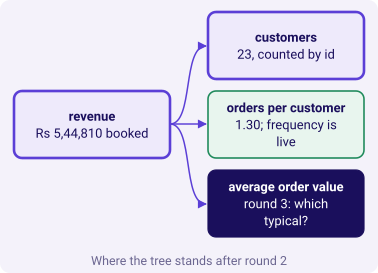

In [16]:
kit.table(["What we now know", "The evidence"],
          [("A row is an order; customers are counted by distinct id", "30 rows, 23 customers"),
           ("Frequency is a live branch", "1.30 orders per customer; 7 of 23 customers came back"),
           ("The tree multiplies back to revenue", "23 x 1.30 x Rs 18,160 = Rs 5,44,810"),
           ("The definition moves every leaf", "delivered: 21 orders, 19 customers, 1.11, Rs 5,20,790")],
          caption="Round 2: the leaves, counted")
kit.driver_tree({"label": "revenue", "note": "Rs 5,44,810 booked", "kind": "known", "children": [
    {"label": "customers", "note": "23, counted by id", "kind": "known"},
    {"label": "orders per customer", "note": "1.30; frequency is live", "kind": "good"},
    {"label": "average order value", "note": "round 3: which typical?", "kind": "lit"}]},
    title="Where the tree stands after round 2")

In [17]:
kit.check_summary()
print("Next: round 3 asks whether Rs 18,160 describes a typical Kalpa order, and which 'typical' is honest.")

Next: round 3 asks whether Rs 18,160 describes a typical Kalpa order, and which 'typical' is honest.
